In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import matplotlib
#import fitutils as fu
from scipy.signal import find_peaks
import os
import pickle
import csv
import re
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import copy  # pour éviter de modifier les données partagées
import pandas as pd

In [4]:
system_loc = 'windows_server'

## Load files (outputs from rdd...)

In [5]:
if system_loc=='linux_server':
    pkl_file_lists = "/media/turbots/GreDisk/Gre25/Summary/dispersion_relations/resultats/dict_lists.pkl"
    pkl_file_results = "/media/turbots/GreDisk/Gre25/Summary/dispersion_relations/resultats/dict_results.pkl"
elif system_loc=='windows_server':
    pkl_file_lists = "R:/Gre25/Summary/dispersion_relations/resultats/dict_lists.pkl"
    pkl_file_results = "R:/Gre25/Summary/dispersion_relations/resultats/dict_results.pkl"
elif system_loc=='windows_local':
    pkl_file_lists = "D:/Grenoble/Gre25/Summary/dispersion_relations/resultats/dict_lists.pkl"
    pkl_file_results = "D:/Grenoble/Gre25/Summary/dispersion_relations/resultats/dict_results.pkl"

# load pickle file
with open(pkl_file_lists, "rb") as f:
    dict_lists = pickle.load(f)

with open(pkl_file_results, "rb") as f:
    dict_results = pickle.load(f)

## Plot all dispersion relations

(1.0, 50.0)

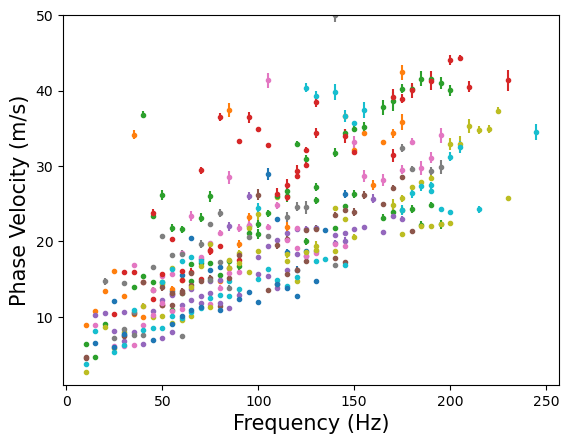

In [6]:
#%% plot des relations de dispersion

for date in dict_results:
    for acq in dict_results[date]:
        for cam in dict_results[date][acq]:
            ddd = dict_results[date][acq][cam]
            tab_v_phase = ddd['tab_v_phase']
            tab_v_phase_err = ddd['tab_v_phase_err']
            tab_f_exc = ddd['tab_f_exc']
            mask = (tab_v_phase_err < 1/30*tab_v_phase) & (tab_v_phase>0)# & (tab_f_exc<100)

            plt.errorbar(tab_f_exc[mask],tab_v_phase[mask],tab_v_phase_err[mask],marker='.',linestyle='')
plt.xlabel('Frequency (Hz)',fontsize=15)
plt.ylabel('Phase Velocity (m/s)',fontsize=15)
plt.ylim(1,50)
#plt.loglog()


In [7]:
print(dict_lists)

{'list_acq_num': [2, 4, 2, 2, 4, 4, 2, 2, 3, 3, 2, 2, 4, 4, 5, 5, 7, 7, 2, 3, 4], 'list_W': [64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64], 'list_Dt': [50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50], 'list_camera_SN': ['40300722', '40300722', '40300722', '40300722', '40300722', '40307970', '40300722', '40307970', '40300722', '40307970', '40300722', '40307970', '40300722', '40307970', '40300722', '40307970', '40300722', '40307970', '40307970', '40307970', '40307970'], 'list_indices_profile_line': [2, 3, 3, 2, 4, 2, 3, 3, 7, 6, 2, 2, 3, 2, 4, 3, 3, 3, 2, 3, 3], 'x_inf_fit': [0, 0, 0, 0, 0, 15, 0, 0, 0, 0, 0, 0, 0, 20, 0, 0, 0, 0, 0, 0, 0], 'x_sup_fit': [25, 35, 40, 30, 35, 50, 30, 50, 30, 50, 30, 30, 40, 55, 30, 55, 35, 55, 55, 55, 50], 'list_dcm': [16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 8.0, 10.0], 'list_dpx': [1452.0, 1452.0, 1452.0, 1452

## Lecture des données d'épaisseurs et rangement dans dict

In [ ]:

#%% maintenant aller chercher les épaisseurs, et plot vphase/(h**3/5) vs freq 




list_h_avg = []
list_h_err = []

for i in range(len(dict_lists['list_acq_num'])):
    str_date = dict_lists['list_dates'][i][-4:]
    str_acq_num = str(dict_lists['list_acq_num'][i])
    if system_loc=='windows_server':
        data_thickness = np.loadtxt(f'R:/Gre25/Data/thicknesses/thicknesses_rdd_{str_date}_acq{str_acq_num}.txt',skiprows=1)
    elif system_loc=='linux_local':
        data_thickness = np.loadtxt(f'/media/vasco/Samsung_T5/Grenoble/Gre25/Data/thicknesses/thicknesses_rdd_{str_date}_acq{str_acq_num}.txt',skiprows=1)
    elif system_loc=='linux_server':
        data_thickness = np.loadtxt(f'/media/turbots/GreDisk/Gre25/Data/thicknesses/thicknesses_rdd_{str_date}_acq{str_acq_num}.txt',skiprows=1)

    #print(f'R:/Gre25/Data/thicknesses/thicknesses_rdd_{dict_lists['\ufeffdate'][i][-4:]}_acq{str(dict_lists['rdd_acq_num'][i])}.txt')
    array_dist = data_thickness[:,0]
    array_h = data_thickness[:,1]
    if dict_lists['list_camera_SN'][i]=='40300722':
        distmin = 5
        distmax = 25
    elif dict_lists['list_camera_SN'][i]=='40307970':
        distmin = 20
        distmax = 45        
    idc2avg = np.where(((array_dist<=distmax)&(array_dist>=distmin))|(np.isnan(array_dist)))

    #print(idc2avg)
    h_avg = np.nanmean(array_h[idc2avg])
    list_h_avg.append(h_avg)
    h_std = np.nanstd(array_h[idc2avg])
    list_h_err.append(h_std)
    print(dict_lists['list_dates'][i] , 'acq_'+str(dict_lists['list_acq_num'][i]), 'camera', dict_lists['list_camera_SN'][i])
    print('h = '+str(h_avg) + ' +- ' + str(h_std))

    dd = dict_results[dict_lists['list_dates'][i]]['acq_'+str(dict_lists['list_acq_num'][i])]['camera_'+str(dict_lists['list_camera_SN'][i])]

    dd['h_avg_mm'] = h_avg
    dd['h_std_mm'] = h_std





## PLOT

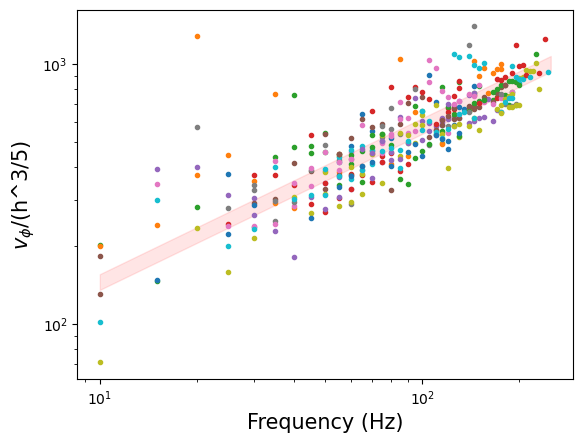

In [9]:
plt.figure()
for date in dict_results:
    for acq in dict_results[date]:
        for cam in dict_results[date][acq]:
            ddd = dict_results[date][acq][cam]
            tab_v_phase = ddd['tab_v_phase']
            tab_v_phase_err = ddd['tab_v_phase_err']
            tab_f_exc = ddd['tab_f_exc']
            h_avg = ddd['h_avg_mm'] * 1e-3
            h_std = ddd['h_std_mm'] * 1e-3
            mask = (tab_v_phase_err < 1/30*tab_v_phase) & (tab_v_phase>0)# & (tab_f_exc<100)

            plt.plot(tab_f_exc[mask],tab_v_phase[mask] / (h_avg**(3/5)),marker='.',linestyle='')

plt.xlabel('Frequency (Hz)',fontsize=15)
plt.ylabel('$v_{\phi}$/(h^3/5)',fontsize=15)
#plt.ylim(1,20)
plt.loglog()

Einf = 2e9
rho = 1e3
tab_freq_test = np.linspace(10,250)
tab_v_phase_normalise_ep_inf= (Einf/(12*(1-0.3**2)))**(1/5) * (1/(rho**(1/5))) * (2*np.pi*tab_freq_test)**(3/5)


Esup = 4e9
rho = 1e3
#tab_freq_test = np.linspace(10,250)
tab_v_phase_normalise_ep_sup= (Esup/(12*(1-0.3**2)))**(1/5) * (1/(rho**(1/5))) * (2*np.pi*tab_freq_test)**(3/5)

#plt.plot(tab_freq_test,tab_v_phase_normalise_ep_inf)
#plt.plot(tab_freq_test,tab_v_phase_normalise_ep_sup)
plt.fill_between(tab_freq_test,tab_v_phase_normalise_ep_inf,tab_v_phase_normalise_ep_sup,color='red',alpha=0.1)

(424,) (424,)
3.6031655943941474
0.4710710151641541
Emoy= 2.88  GPa


[]

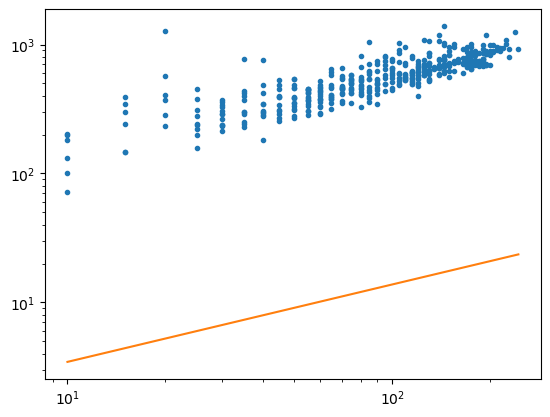

In [10]:
import numpy as np

list_f_exc = []
list_v_phase_normalise = []

for date in dict_results:
    for acq in dict_results[date]:
        for cam in dict_results[date][acq]:
            ddd = dict_results[date][acq][cam]
            tab_v_phase = ddd['tab_v_phase']
            tab_v_phase_err = ddd['tab_v_phase_err']
            tab_f_exc = ddd['tab_f_exc']
            h_avg = ddd['h_avg_mm'] * 1e-3
            h_std = ddd['h_std_mm'] * 1e-3

            # mask: exclude noisy data or invalid ones
            mask = (tab_v_phase_err < 1/30 * tab_v_phase) & (tab_v_phase > 0)

            # apply mask and normalisation
            f_exc_filtered = tab_f_exc[mask]
            v_phase_normalise = tab_v_phase[mask] / (h_avg**(3/5))

            # accumulate
            list_f_exc.append(f_exc_filtered)
            list_v_phase_normalise.append(v_phase_normalise)

# convert to numpy arrays
all_f_exc = np.concatenate(list_f_exc)
all_v_phase_normalise = np.concatenate(list_v_phase_normalise)

# optional: print or return for debugging
print(all_f_exc.shape, all_v_phase_normalise.shape)


def vphi_normalise_flexural(freq,E,rho=1e3,nu=0.33):
    return (E/(rho*12*(1-nu**2)))**(1/5) * (2*np.pi*freq)**(3/5)


#############
# "fit" en sachant déjà la pente (donc moyenne)

b = np.mean(np.log(all_v_phase_normalise) - (3/5)*np.log(all_f_exc))
print(b)
rho=1e3
nu=0.33
B = ((1/(rho*(12*(1-nu**2))))**(1/5))*(2*np.pi)**(3/5)
print(B)
Emoy = 5*(b-np.log(B))
print('Emoy=',np.round(1e-9*np.exp(Emoy),2),' GPa')
#############



plt.plot(all_f_exc,all_v_phase_normalise,'.')
fvals=np.linspace(np.min(all_f_exc),np.max(all_f_exc))
plt.plot(fvals,(Emoy/(12*(1-0.3**2)))**(1/5) * (1/(rho**(1/5))) * (2*np.pi*fvals)**(3/5))
plt.loglog()

## choose the nicer dispersion relation

C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_13624\167862044.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


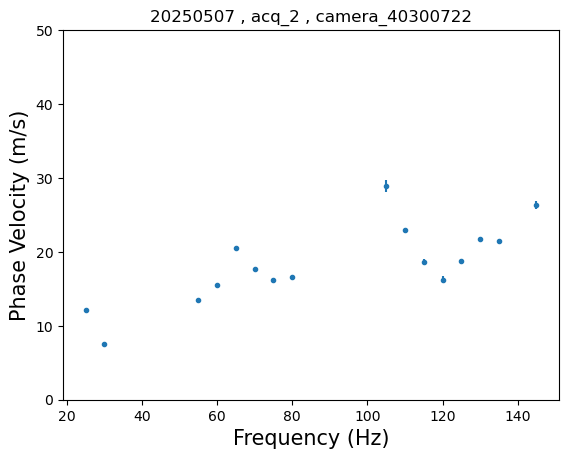

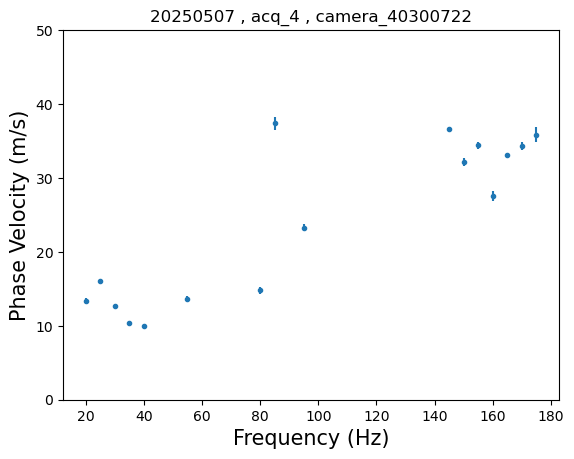

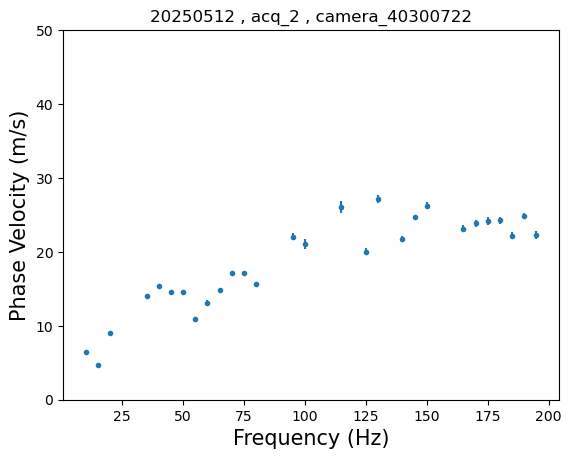

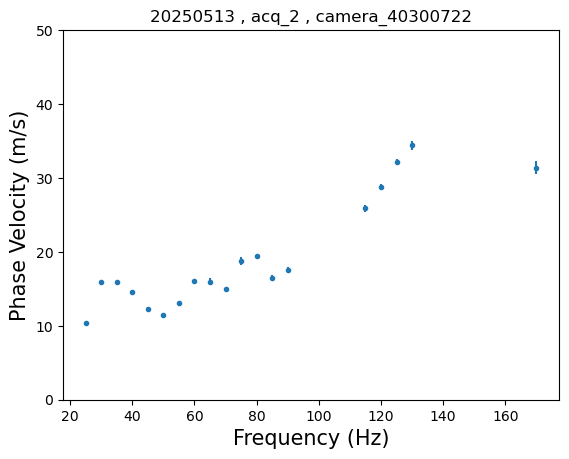

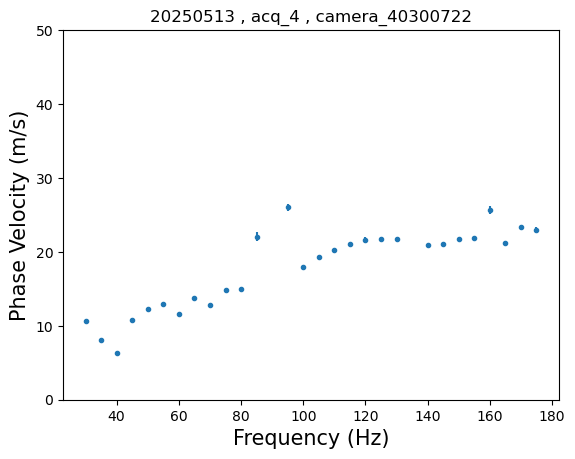

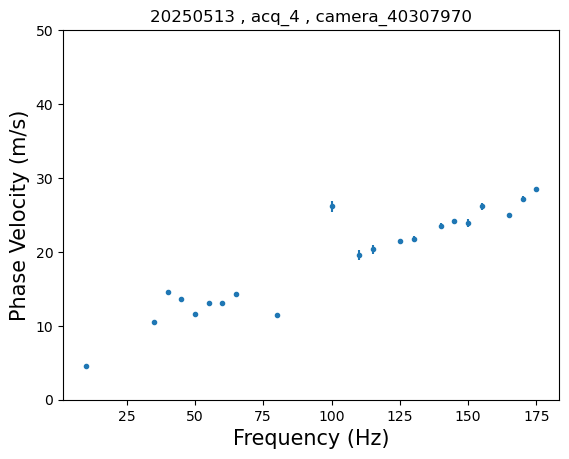

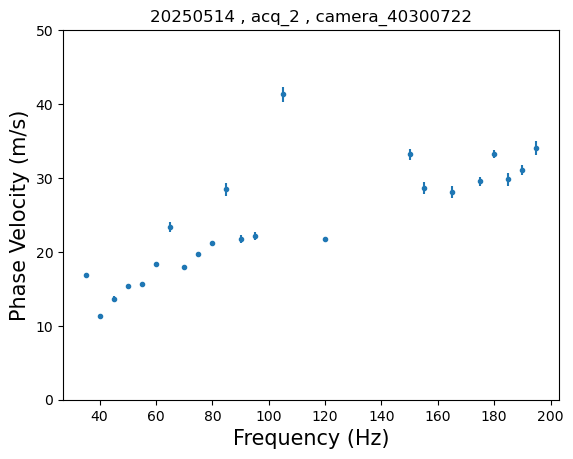

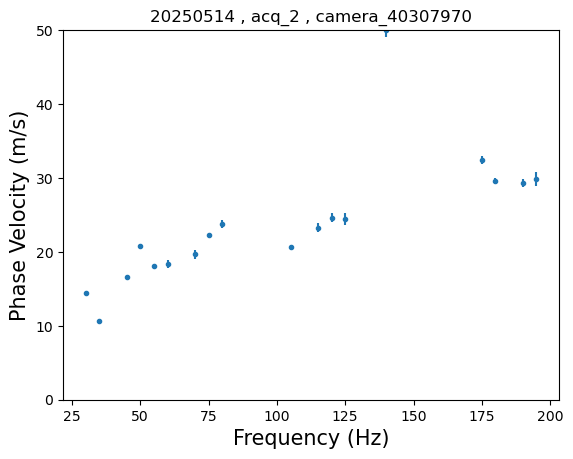

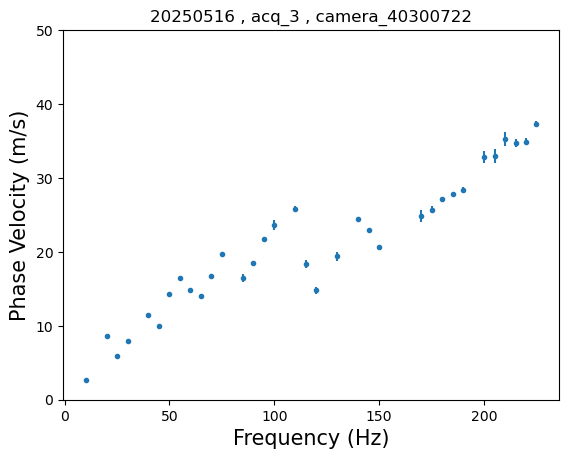

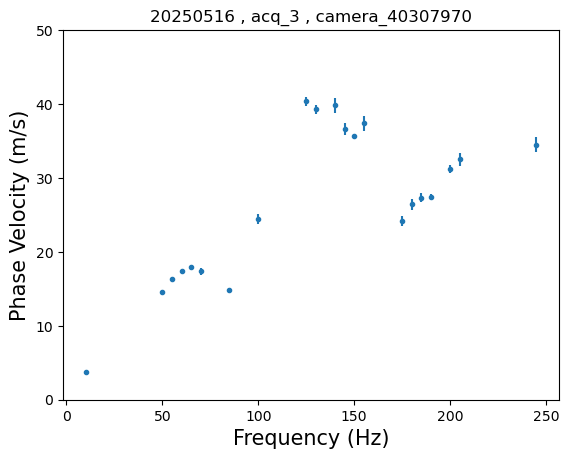

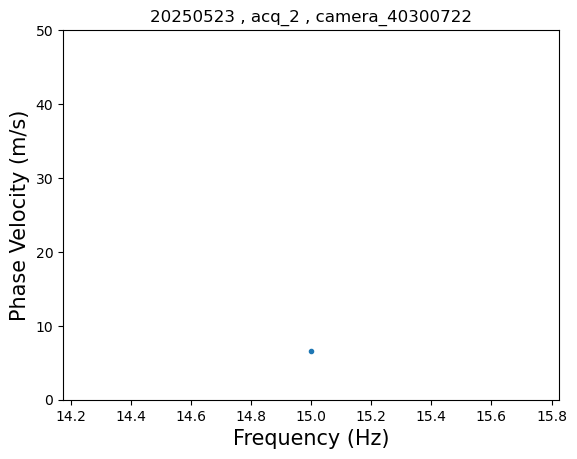

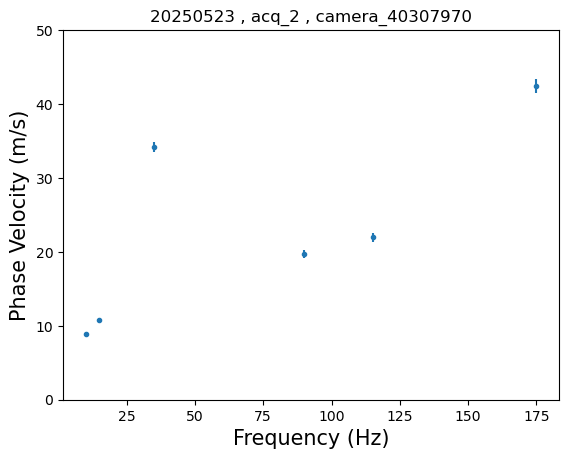

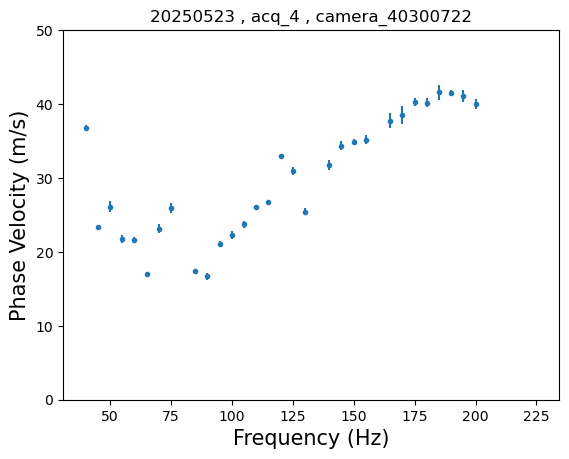

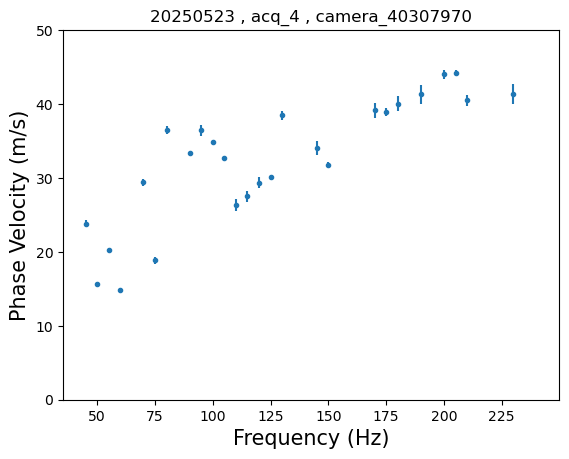

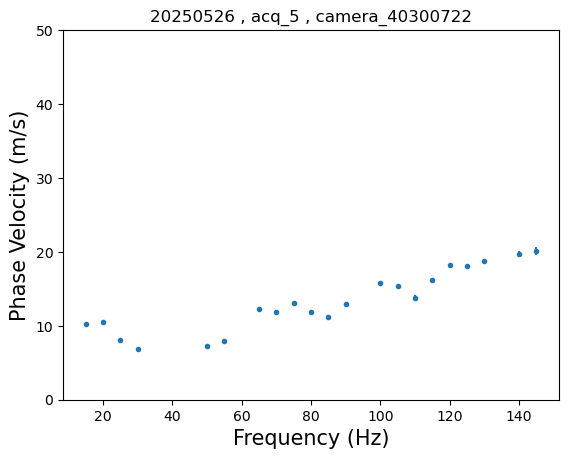

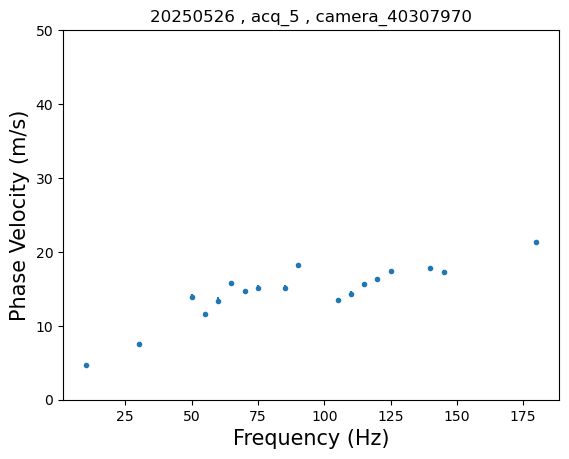

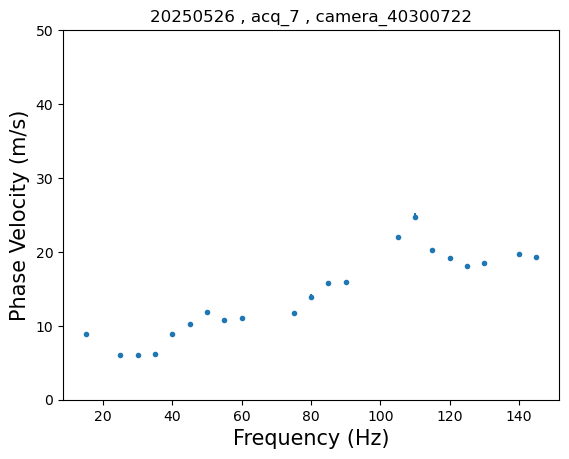

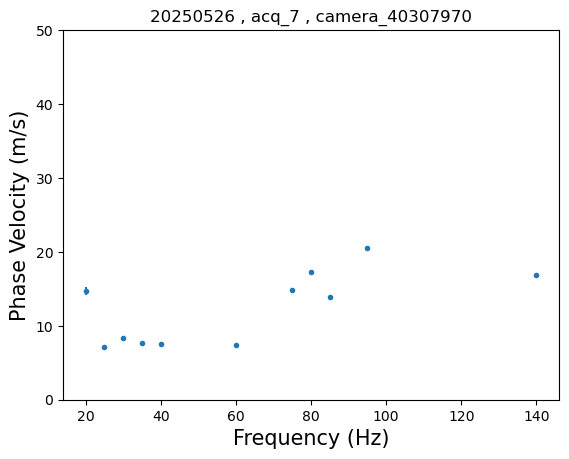

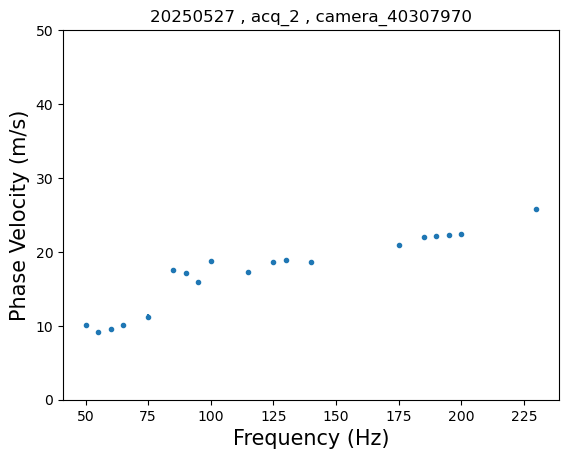

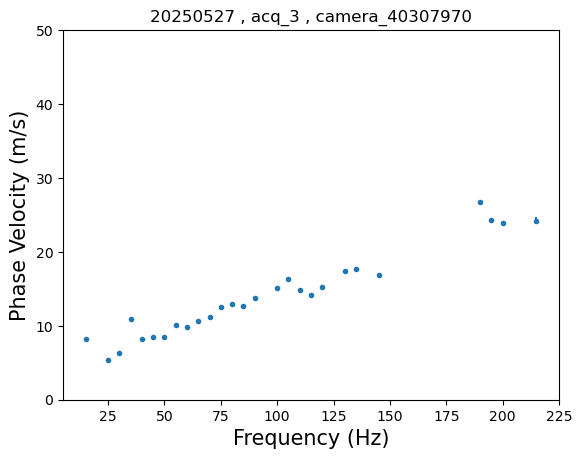

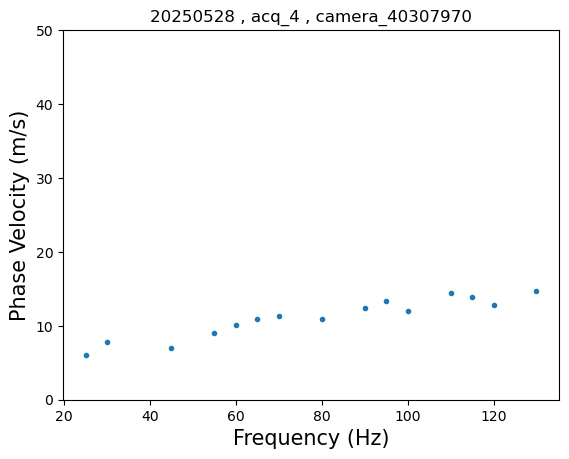

In [18]:
#%% plot des relations de dispersion

for date in dict_results:
    for acq in dict_results[date]:
        for cam in dict_results[date][acq]:

            ddd = dict_results[date][acq][cam]
            tab_v_phase = ddd['tab_v_phase']
            tab_v_phase_err = ddd['tab_v_phase_err']
            tab_f_exc = ddd['tab_f_exc']
            mask = (tab_v_phase_err < 1/30*tab_v_phase) & (tab_v_phase>0)# & (tab_f_exc<100)
            plt.figure()
            plt.title(date+' , '+acq+' , '+cam)
            plt.errorbar(tab_f_exc[mask],tab_v_phase[mask],tab_v_phase_err[mask],marker='.',linestyle='')
            plt.xlabel('Frequency (Hz)',fontsize=15)
            plt.ylabel('Phase Velocity (m/s)',fontsize=15)
            plt.ylim(0,50)
            #plt.loglog()

#13/05 acq4 et 27/05 acq3 sont les mieux

FileNotFoundError: [Errno 2] No such file or directory: 'resultats/figures/rdd_20250513_acq_4_camera_40307970.pdf'

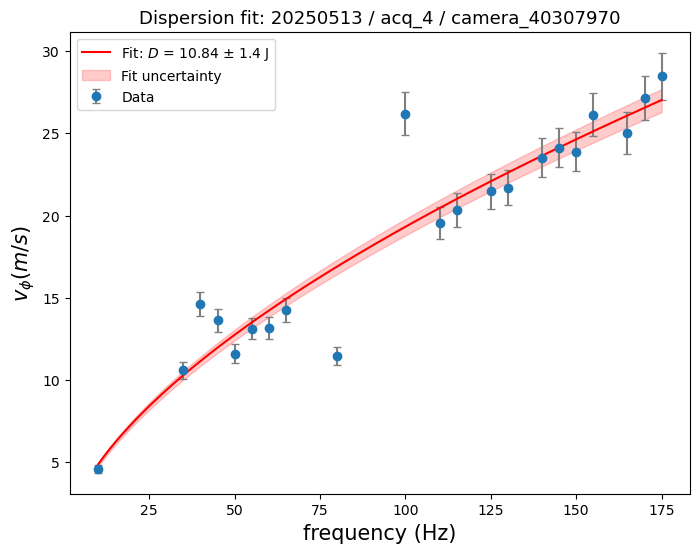

In [19]:
# afficher les deux meilleurs et fitter pour avoir D
# d'abord on définit la fonction qui calcule v_phase vs la frequence
def v_phase_flexural(f,D):
    rho=1e3
    omega = 2*np.pi*f
    return (D/rho)**(1/5) * omega**(3/5)
#########################################################################

def plot_fit_onedataset(date, acq, cam, bounds=(0, np.inf),errorbar_echelle=True):
    """
    Plot dispersion data with fitted flexural wave model.
    """
    ddd = dict_results[date][acq][cam]
    tab_v_phase = ddd['tab_v_phase']
    tab_v_phase_err = ddd['tab_v_phase_err']
    tab_f_exc = ddd['tab_f_exc']
    
    mask = (
        (tab_v_phase_err < 1/30 * tab_v_phase) &
        (tab_v_phase > 0) &
        (tab_f_exc > bounds[0]) &
        (tab_f_exc < bounds[1])
    )


    # Fit model
    popt, pcov = curve_fit(
        v_phase_flexural,
        tab_f_exc[mask],
        tab_v_phase[mask],
        sigma=tab_v_phase_err[mask],
        absolute_sigma=False
    )

    D_fit = popt[0]
    D_err = np.sqrt(np.diag(pcov))[0]

    # Plot
    plt.figure(figsize=(8, 6))
    if errorbar_echelle:
        yerr=tab_v_phase[mask] * 0.05
    elif errorbar_echelle==False:
        yerr=tab_v_phase_err[mask]
    plt.errorbar(
        tab_f_exc[mask],
        tab_v_phase[mask],
        yerr=yerr,
        fmt='o',
        ecolor='gray',
        capsize=3,
        label='Data'
    )
    
    f_fit = np.linspace(min(tab_f_exc[mask]), max(tab_f_exc[mask]), 300)
    v_fit = v_phase_flexural(f_fit, D_fit)
    v_fit_upper = v_phase_flexural(f_fit, D_fit + D_err)
    v_fit_lower = v_phase_flexural(f_fit, D_fit - D_err)

    plt.plot(f_fit, v_fit, 'r-', label=f'Fit: $D$ = {np.round(D_fit,2)} ± {np.round(D_err,2)} J')
    plt.fill_between(f_fit, v_fit_lower, v_fit_upper, color='red', alpha=0.2, label='Fit uncertainty')

    # Labels and legend
    plt.xlabel('Frequency (Hz)', fontsize=14)
    plt.ylabel('Phase velocity $v_\\phi$ (m/s)', fontsize=14)
    plt.title(f'Dispersion fit: {date} / {acq} / {cam}', fontsize=13)
    plt.legend()
    #plt.grid(True, which='both', linestyle='--', alpha=0.6)

    # save the data points (+ the mask)
    data2save = np.column_stack((tab_f_exc,tab_v_phase,tab_v_phase_err,mask))
    plt.xlabel('frequency (Hz)',fontsize=15)
    plt.ylabel('$v_{\phi} (m/s)$',fontsize=15)
    plt.legend()
    #plt.tight_layout()
    plt.savefig('resultats/figures/rdd_'+date+'_'+acq+'_'+cam+'.pdf',dpi=300)
    plt.show()

    np.savetxt('resultats/figures/datapoints_'+date+'_'+acq+'_'+cam+'.txt',data2save)

    return ddd, popt, pcov, tab_f_exc, tab_v_phase, tab_v_phase_err


##########################################################################
ddd1, popt1,pcov1, tab_f_exc1, tab_v_phase1, tab_v_phase_err1 = plot_fit_onedataset('20250513', 'acq_4', 'camera_40307970',bounds=(0,np.inf))
#plt.show()
##########################################################################
#plt.figure()
ddd2, popt2,pcov2, tab_f_exc2, tab_v_phase2, tab_v_phase_err2 = plot_fit_onedataset('20250527', 'acq_3', 'camera_40307970', bounds=(0,180))

#tab_v_phase2 = tab_v_phase2*(1452/16)*(8/789)
#plt.show()
##########################################################################
#ddd3, popt3,pcov3 = plot_fit_onedataset('20250527' , 'acq_2', 'camera_40307970', bounds=(0,250))


ddd3, popt3,pcov3, tab_f_exc3, tab_v_phase3, tab_v_phase_err3  = plot_fit_onedataset('20250523', 'acq_4', 'camera_40307970', bounds=(110,250))

#plt.ylim(0,30)
#plt.xlim(0,250)

In [20]:
def flexural(k,D,rho=1e3):
    omega = np.sqrt((D/rho)*k**5)
    return (1/(2*np.pi)) * omega


def plot_fit_onedataset_f_k(date, acq, cam, bounds=(0, np.inf),errorbar_echelle=True):
    """
    Plot dispersion data with fitted flexural wave model.
    """
    ddd = dict_results[date][acq][cam]
    tab_v_phase = ddd['tab_v_phase']
    tab_v_phase_err = ddd['tab_v_phase_err']
    tab_f_exc = ddd['tab_f_exc']
    
    mask = (
        (tab_v_phase_err < 1/30 * tab_v_phase) &
        (tab_v_phase > 0) &
        (tab_f_exc > bounds[0]) &
        (tab_f_exc < bounds[1])
    )


    # Fit model
    popt, pcov = curve_fit(
        v_phase_flexural,
        tab_f_exc[mask],
        tab_v_phase[mask],
        sigma=tab_v_phase_err[mask],
        absolute_sigma=False
    )

    D_fit = popt[0]
    D_err = np.sqrt(np.diag(pcov))[0]

    # Plot
    plt.figure(figsize=(8, 6))

    tab_k = 2*np.pi*tab_f_exc/tab_v_phase

    if errorbar_echelle:
#        yerr=tab_v_phase[mask] * 0.05
        tab_k_err = 2*np.pi*tab_f_exc*(1/tab_v_phase**2)*(tab_v_phase*0.05)
    elif errorbar_echelle==False:
        tab_k_err = 2*np.pi*tab_f_exc*(1/tab_v_phase**2)*(tab_v_phase_err)
#        yerr=tab_v_phase_err[mask]
    
    plt.errorbar(
        tab_k[mask],
        tab_f_exc[mask],
        xerr=tab_k_err[mask],
        fmt='o',
        ecolor='gray',
        capsize=3,
        label='Data'
    )
    
    #f_fit = np.linspace(min(tab_f_exc[mask]), max(tab_f_exc[mask]), 300)
    #v_fit = v_phase_flexural(f_fit, D_fit)
    #v_fit_upper = v_phase_flexural(f_fit, D_fit + D_err)
    #v_fit_lower = v_phase_flexural(f_fit, D_fit - D_err)

    k_fit = np.linspace(min(tab_k[mask]), max(tab_k[mask]), 300)
    f_fit = flexural(k_fit,D_fit)
    f_fit_upper = flexural(k_fit, D_fit + D_err)
    f_fit_lower = flexural(k_fit, D_fit - D_err)
    

    plt.plot(k_fit, f_fit, 'r-', label=f'Fit: $D$ = {np.round(D_fit,2)} ± {np.round(D_err,2)} J')
    plt.fill_between(k_fit, f_fit_lower, f_fit_upper, color='red', alpha=0.2, label='Fit uncertainty')

    # Labels and legend
    #plt.xlabel('k ($m^-1)', fontsize=14)
    #plt.ylabel('Phase velocity $v_\\phi$ (m/s)', fontsize=14)
    plt.title(f'Dispersion fit: {date} / {acq} / {cam}', fontsize=15)
    #plt.legend()
    #plt.grid(True, which='both', linestyle='--', alpha=0.6)

    # save the data points (+ the mask)
    data2save = np.column_stack((tab_f_exc,tab_v_phase,tab_v_phase_err,mask))
    plt.xlabel('k ($m^{-1}$)',fontsize=20)
    plt.ylabel('f (Hz)',fontsize=20)
    plt.legend()
    #plt.tight_layout()
    plt.savefig('resultats/figures/rdd_f_k_'+date+'_'+acq+'_'+cam+'.pdf',dpi=300)
    plt.show()

    np.savetxt('resultats/figures/datapoints_f_k_'+date+'_'+acq+'_'+cam+'.txt',data2save)

    return ddd, popt, pcov, tab_f_exc, tab_v_phase, tab_v_phase_err

FileNotFoundError: [Errno 2] No such file or directory: 'resultats/figures/rdd_f_k_20250527_acq_3_camera_40307970.pdf'

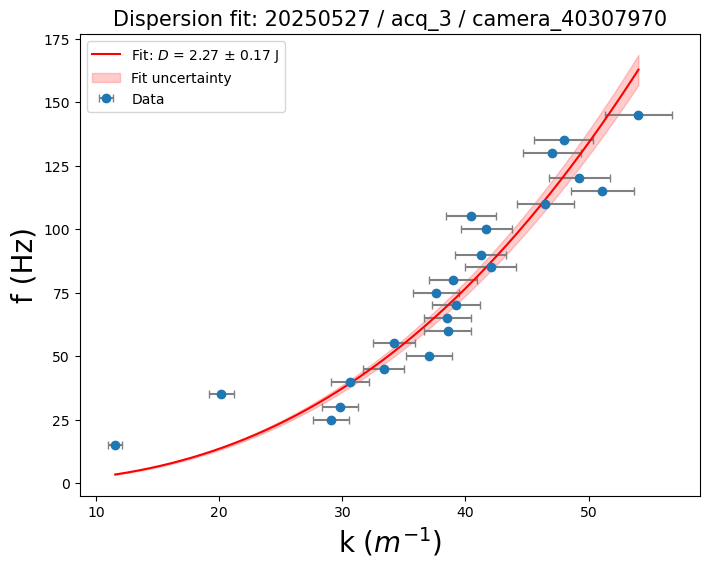

In [21]:
plot_fit_onedataset_f_k('20250527', 'acq_3', 'camera_40307970', bounds=(0,180))

## Estimation of Young's modulus using thicknesses

In [13]:
def compute_E(D,h,h_err,nu=0.33):
    E = (D*12*(1-nu**2))/(h**3)
    E_err = 12*D*(1-nu**2)*3*(1/h**4)*h_err
    # assumes the main contribution on the incertainty is due to the measurement of h
    return E,E_err

E1, E1_err = compute_E(popt1[0],ddd1['h_avg_mm']*1e-3,ddd1['h_std_mm']*1e-3)
E2, E2_err = compute_E(popt2[0],ddd2['h_avg_mm']*1e-3,ddd2['h_std_mm']*1e-3)

E3, E3_err = compute_E(popt3[0],ddd3['h_avg_mm']*1e-3,ddd3['h_std_mm']*1e-3)


print(ddd1['h_avg_mm'])
print(ddd2['h_avg_mm'])
print(ddd3['h_avg_mm'])

print('E1 = ' + str(np.round(E1*1e-9,2))+ ' +- ' + str(np.round(E1_err*1e-9,2))+ ' GPa')
print('E2 = ' + str(np.round(E2*1e-9,2))+ ' +- ' + str(np.round(E2_err*1e-9,2))+ ' GPa')

print('E3 = ' + str(np.round(E3*1e-9,2))+ ' +- ' + str(np.round(E3_err*1e-9,2))+ ' GPa')

3.7550000000000003
2.453333333333333
5.651666666666666
E1 = 2.19 +- 0.16 GPa
E2 = 1.64 +- 0.49 GPa
E3 = 3.94 +- 0.84 GPa


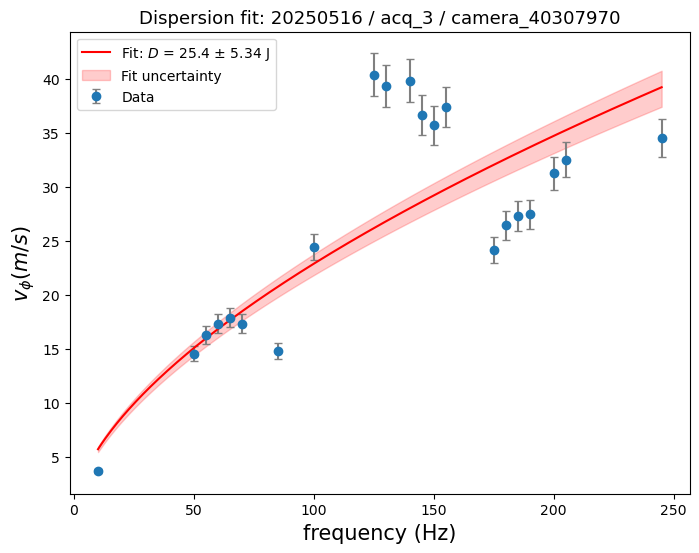

3884182330.4869757 510347327.7329061


In [14]:
#40300722
ddd4, popt4,pcov4, tab_f_exc4, tab_v_phase4, tab_v_phase_err4 = plot_fit_onedataset('20250516', 'acq_3', 'camera_40307970',bounds=(0,np.inf))
E4, E4_err = compute_E(popt4[0],ddd4['h_avg_mm']*1e-3,ddd4['h_std_mm']*1e-3)
print(E4, E4_err)

## Tracé de E vs h

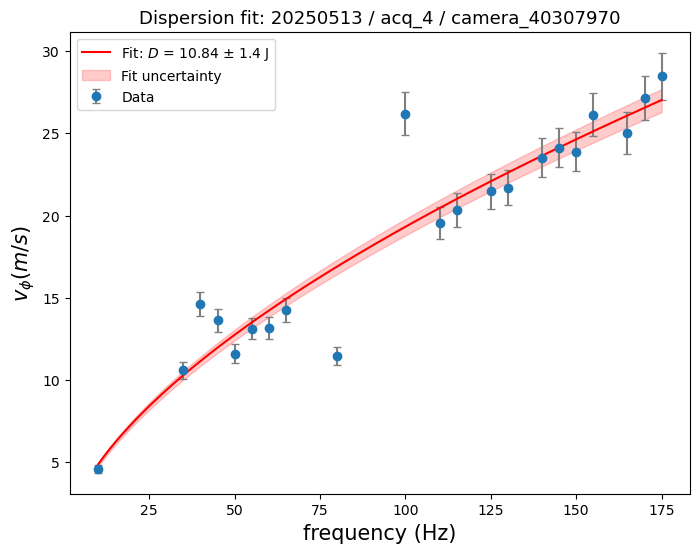

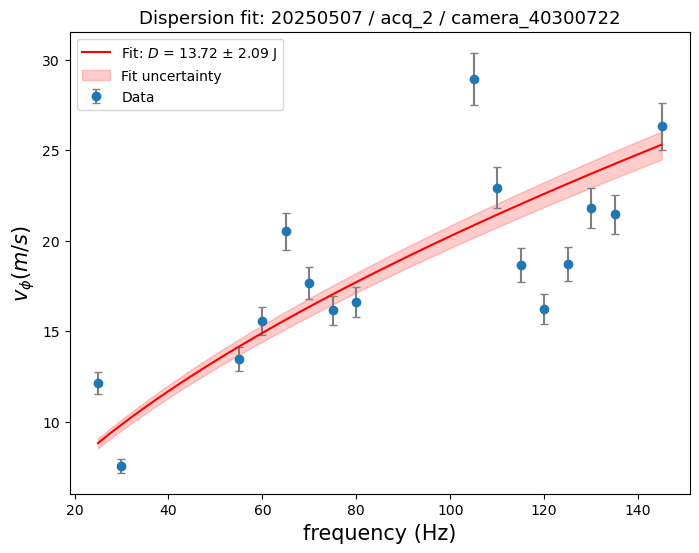

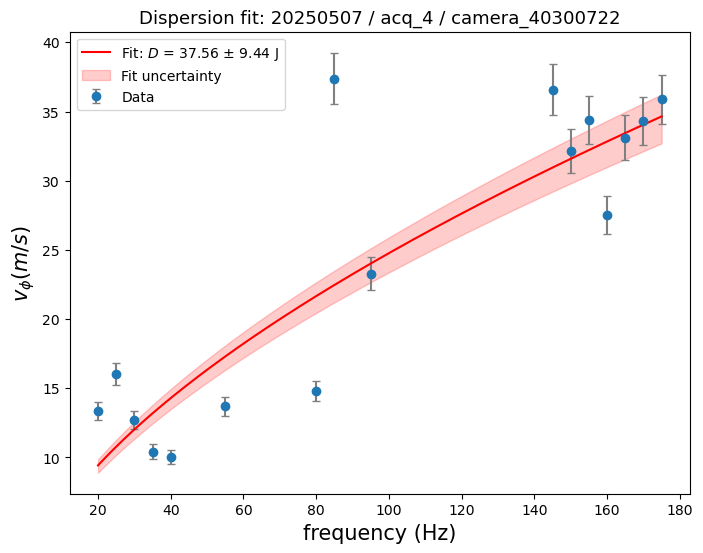

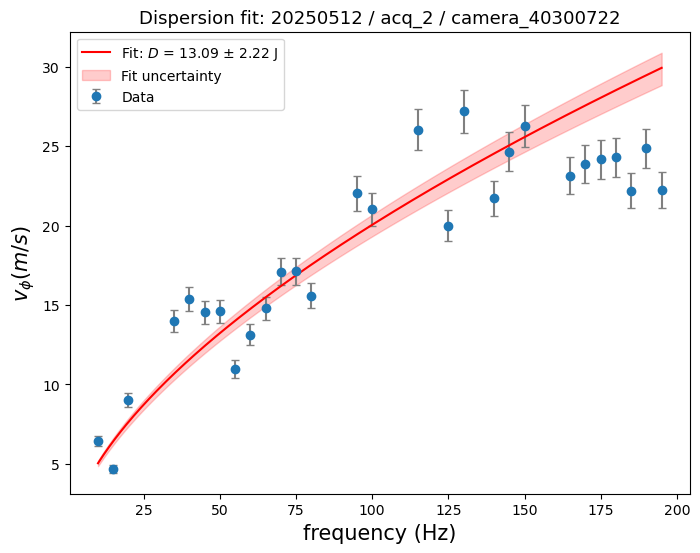

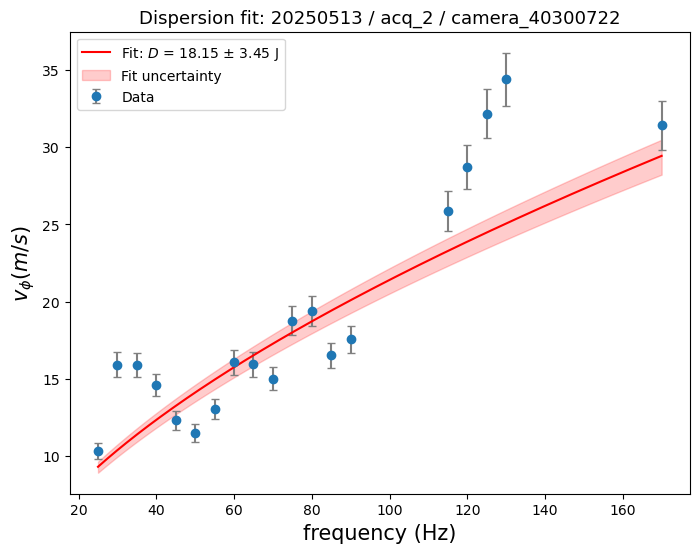

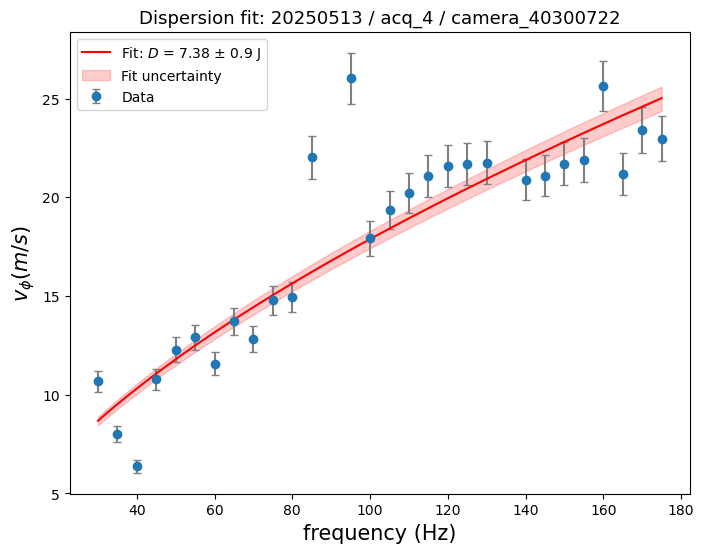

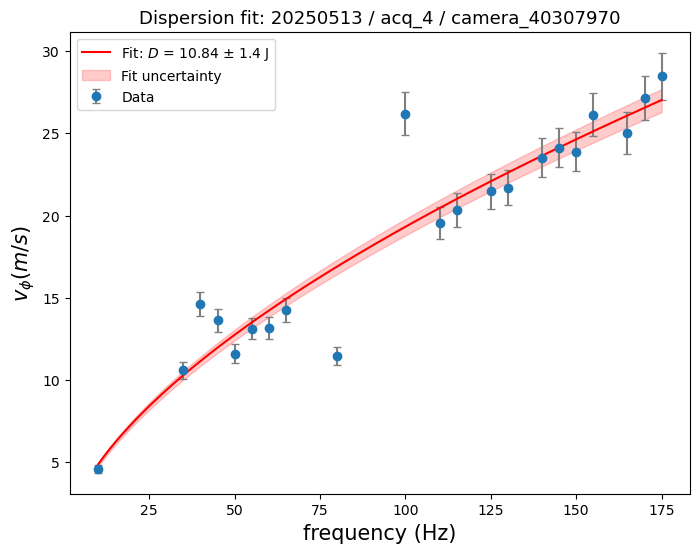

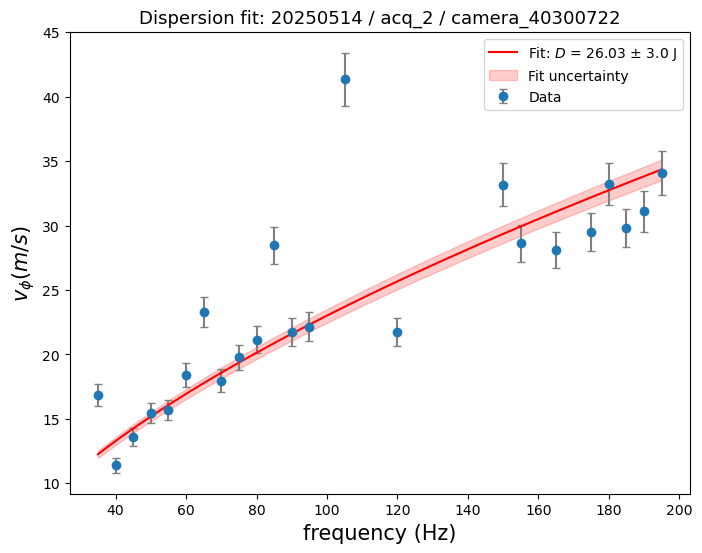

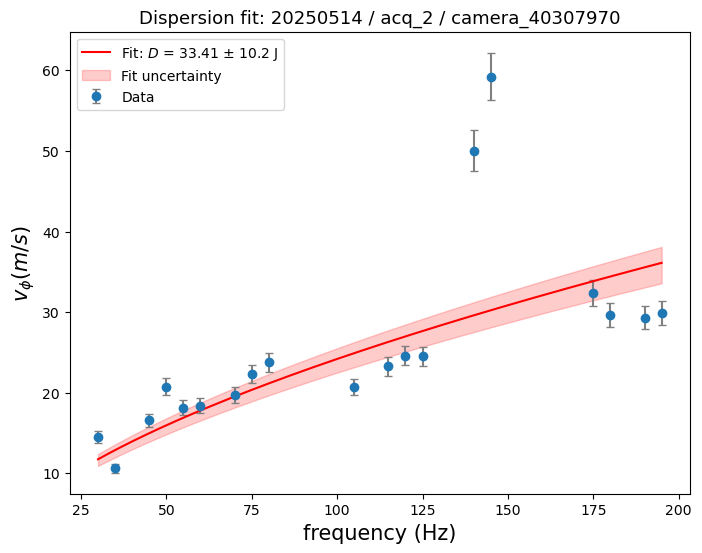

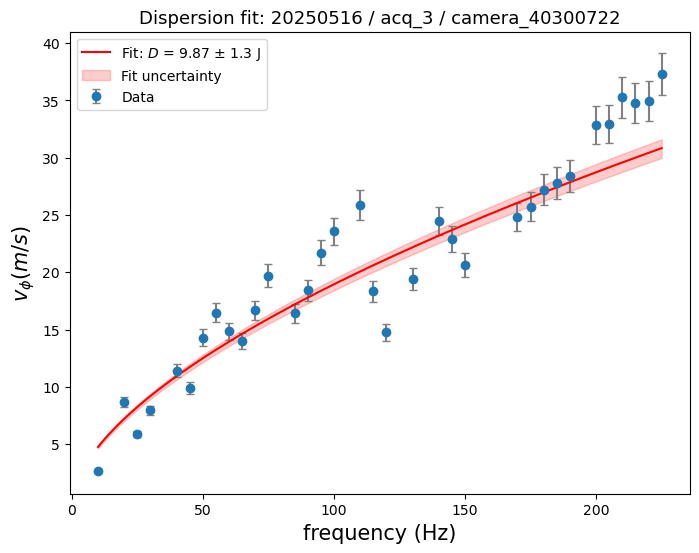

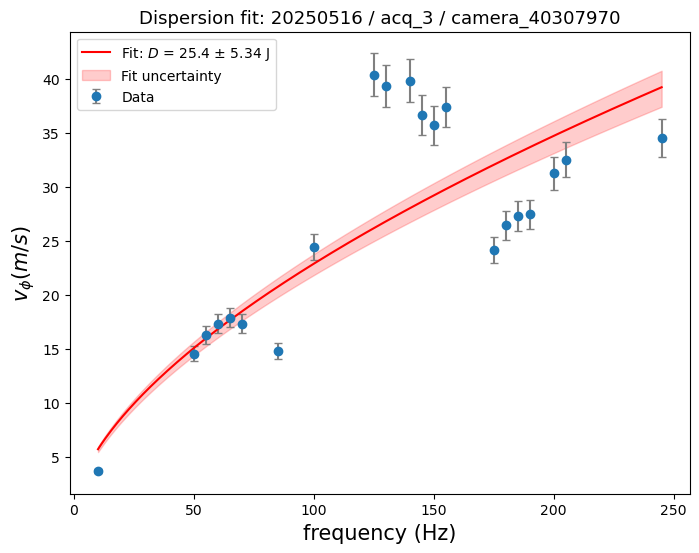

C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_14448\3902980086.py:46: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


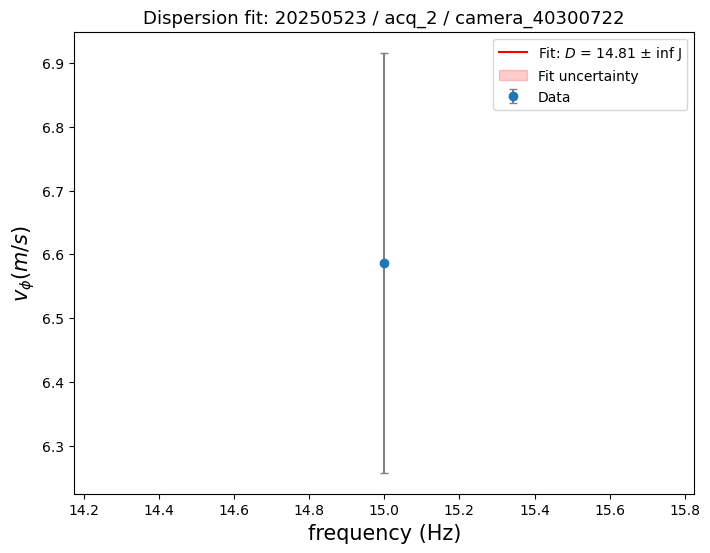

C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_14448\3902980086.py:6: RuntimeWarning: invalid value encountered in scalar power
  return (D/rho)**(1/5) * omega**(3/5)


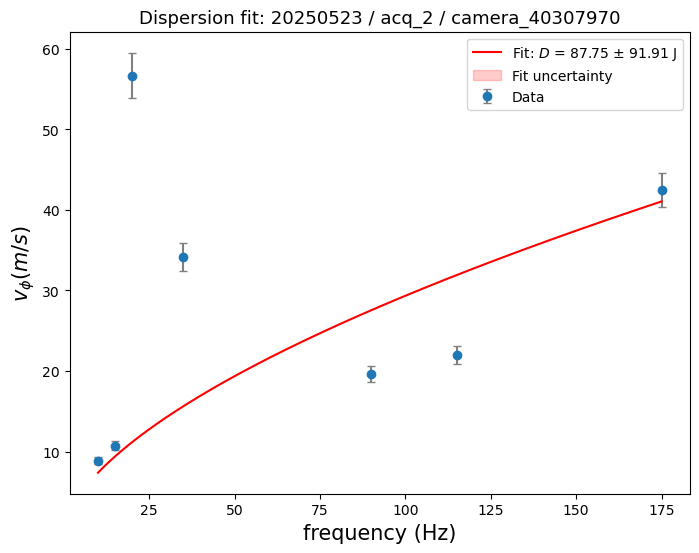

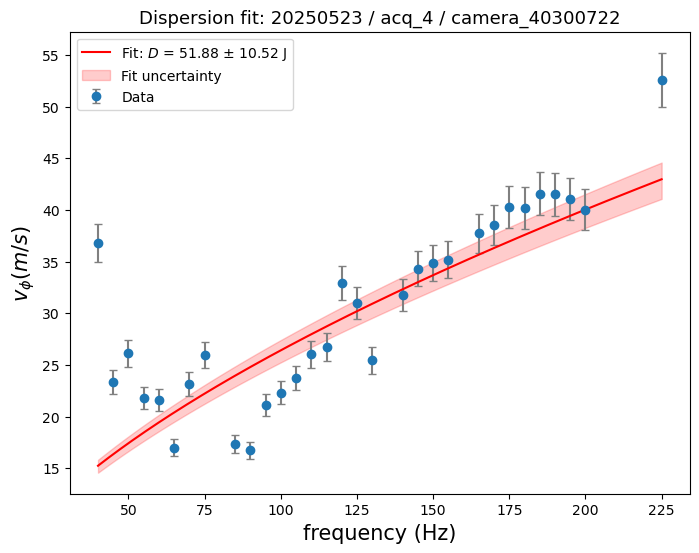

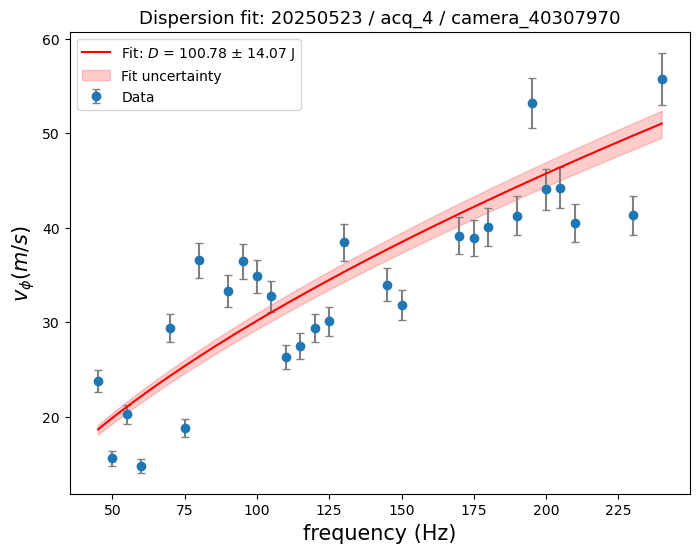

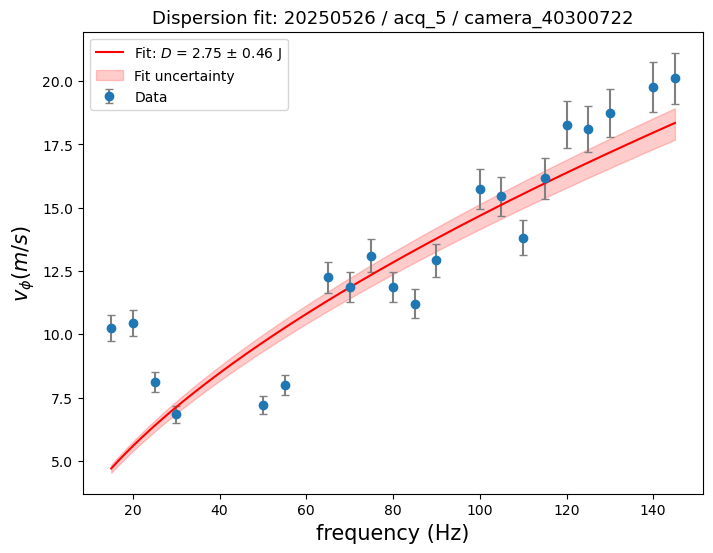

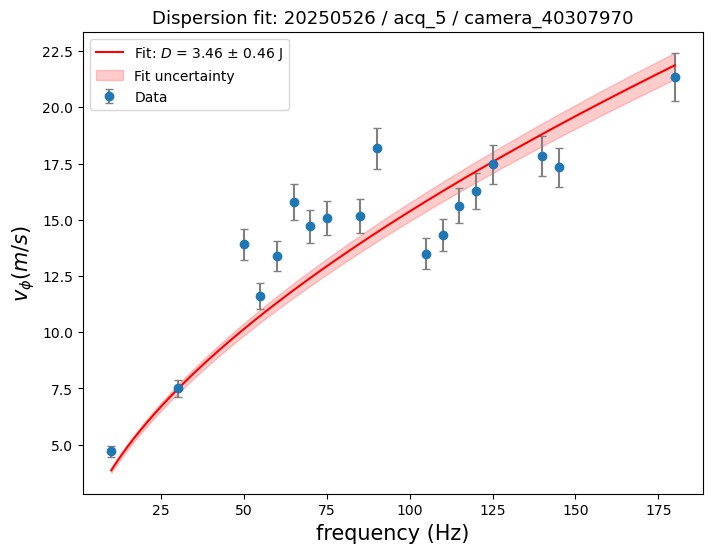

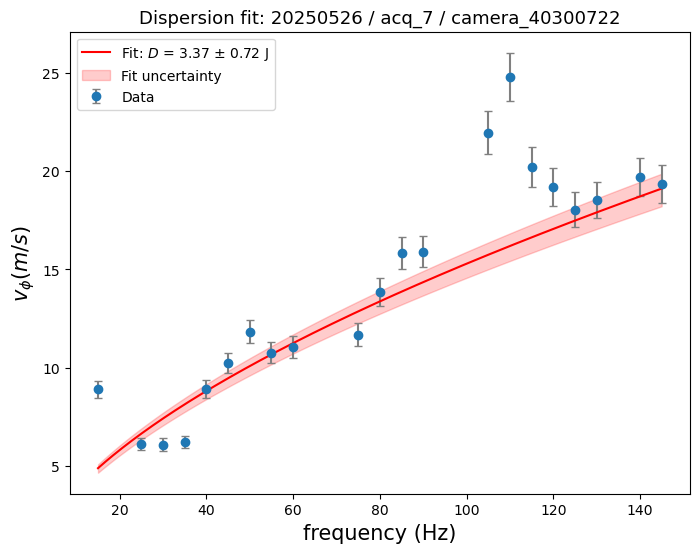

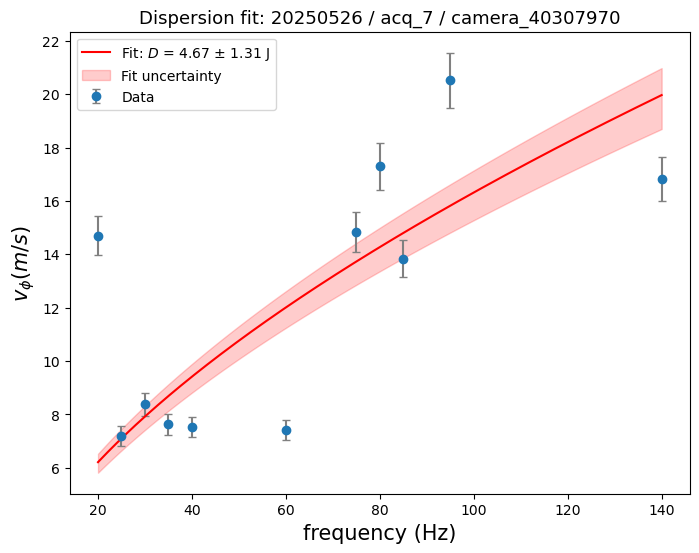

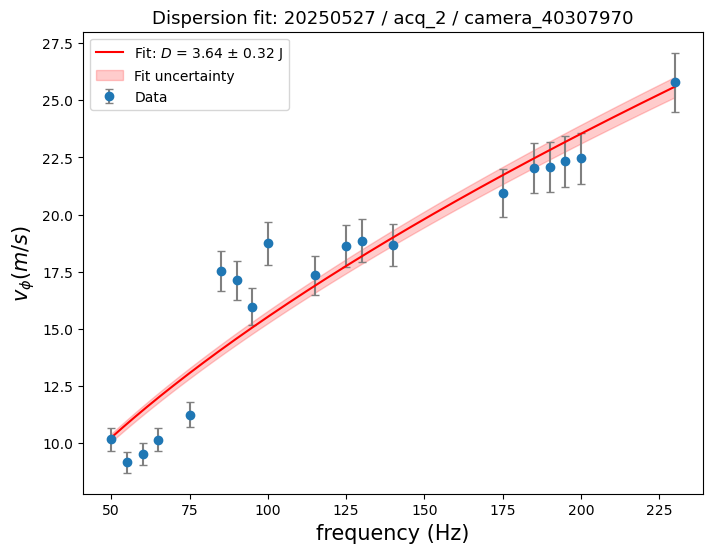

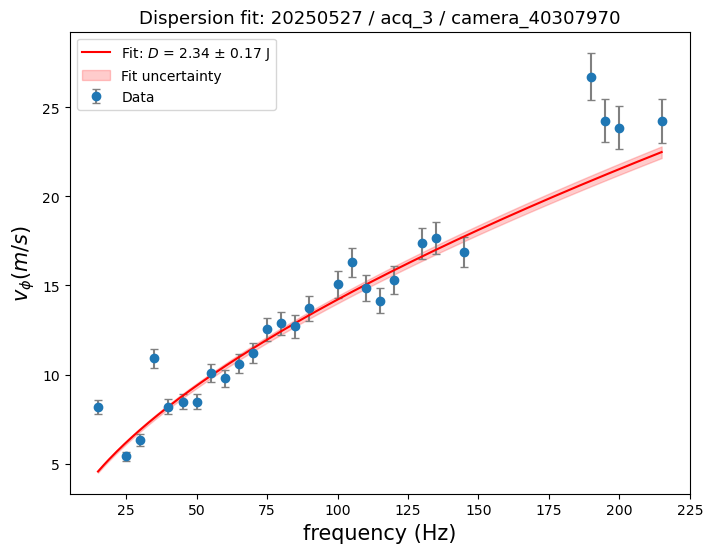

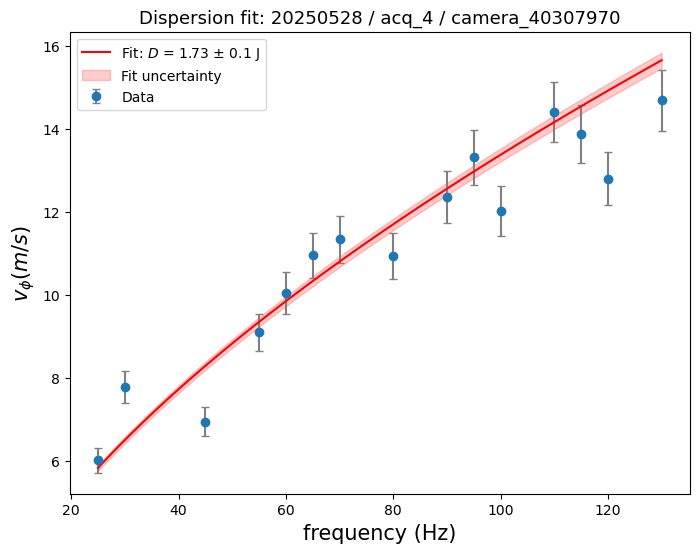

In [15]:
ddd, popt,pcov, tab_f_exc, tab_v_phase, tab_v_phase_err = plot_fit_onedataset('20250513', 'acq_4', 'camera_40307970',bounds=(0,np.inf))



tab_E = []
tab_E_err = []

tab_D = []
tab_D_err = []

tab_h_avg = []
tab_h_std = []


for date in dict_results:
    for acq in dict_results[date]:
        for camera in dict_results[date][acq]:
            ddd, popt,pcov, tab_f_exc, tab_v_phase, tab_v_phase_err = plot_fit_onedataset(date, acq, camera,bounds=(0,np.inf))
            E, E_err = compute_E(popt[0],ddd['h_avg_mm']*1e-3,ddd['h_std_mm']*1e-3)
            tab_E.append(E)
            tab_E_err.append(E_err)
            tab_D.append(popt[0])
            tab_D_err.append(pcov[0][0])            
            tab_h_avg.append(ddd['h_avg_mm']*1e-3)
            tab_h_std.append(ddd['h_std_mm']*1e-3)


tab_E = np.array(tab_E)
tab_E_err = np.array(tab_E_err)
tab_D = np.array(tab_D)
tab_D_err = np.array(tab_D_err)
tab_h_avg = np.array(tab_h_avg)
tab_h_std = np.array(tab_h_std)

<ErrorbarContainer object of 3 artists>

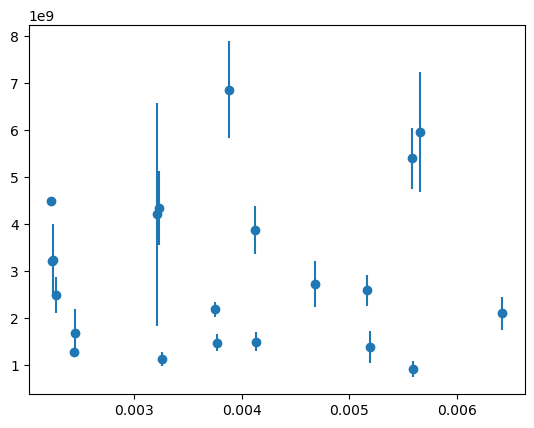

In [16]:
plt.errorbar(tab_h_avg,tab_E,tab_E_err,marker='o',linestyle='')
#plt.xlim(2e-3,3e-3)

## $D$ vs $h^3$

2083025007.1334763
E= 2.0830250071334766 GPa


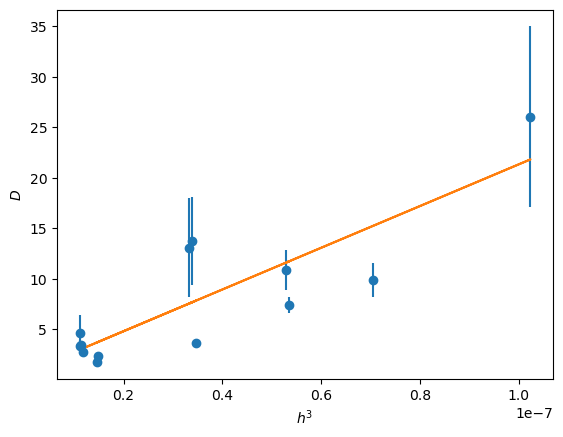

In [17]:
mask = np.where(tab_D_err/tab_D < 1/2)

plt.errorbar(tab_h_avg[mask]**3,tab_D[mask],tab_D_err[mask],marker='o',linestyle='')
#plt.ylim(0,15)

pp = np.polyfit(tab_h_avg[mask]**3,tab_D[mask],1)
a,b = pp[0],pp[1]
plt.plot(tab_h_avg[mask]**3,(tab_h_avg[mask]**3) * a + b )
plt.xlabel('$h^3$')
plt.ylabel('$D$')

print(a * 12*(1-0.4**2))
print('E=',a * 12*(1-0.4**2) * 1e-9,'GPa')


In [18]:
tab_h_avg[mask]

array([0.003234  , 0.003216  , 0.003768  , 0.003755  , 0.004678  ,
       0.00413   , 0.002278  , 0.00225   , 0.00223667, 0.00223   ,
       0.00326167, 0.00245333, 0.00244   ])

## on choisit les plus belles courbes pour voir si ya dependance E vs h

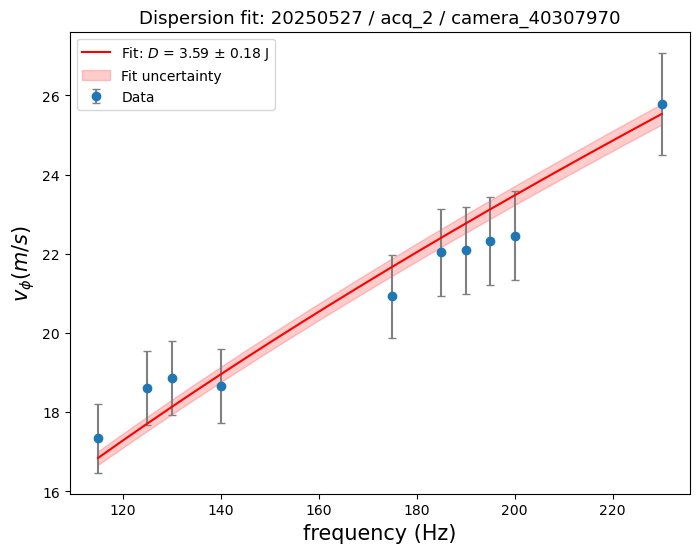

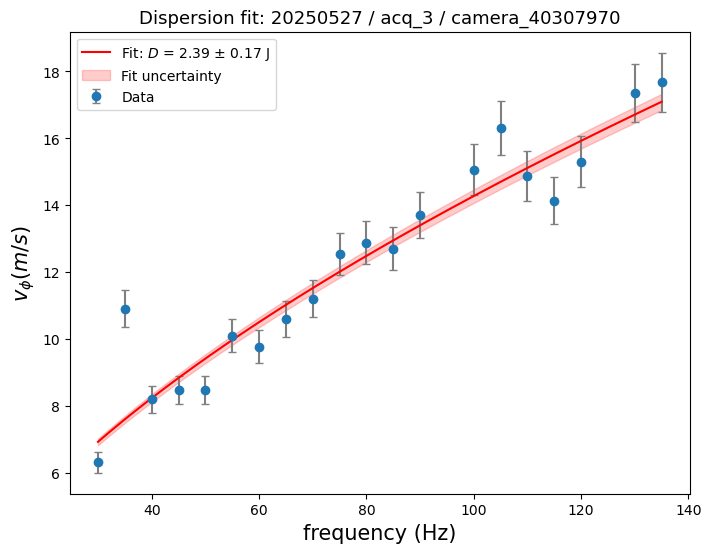

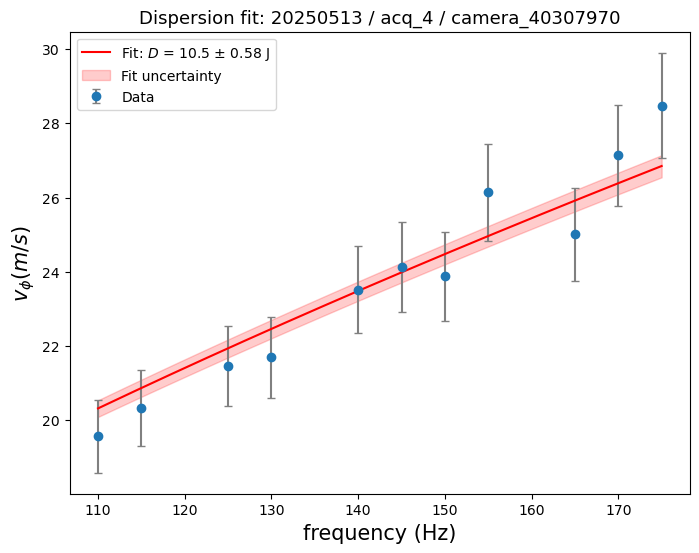

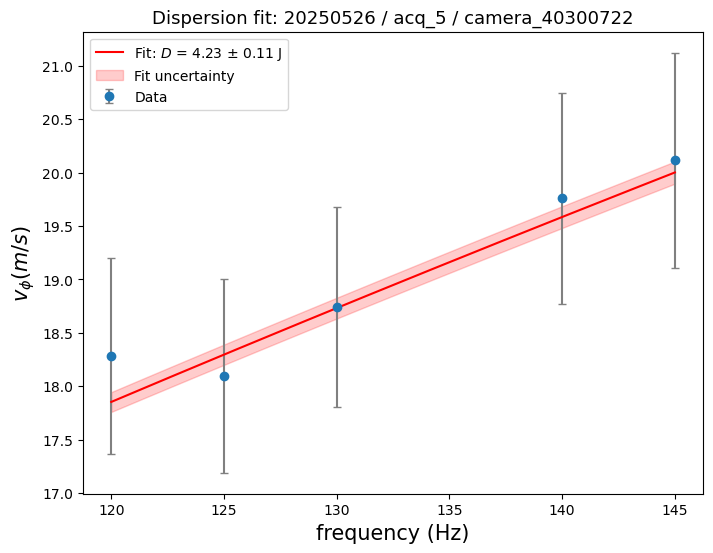

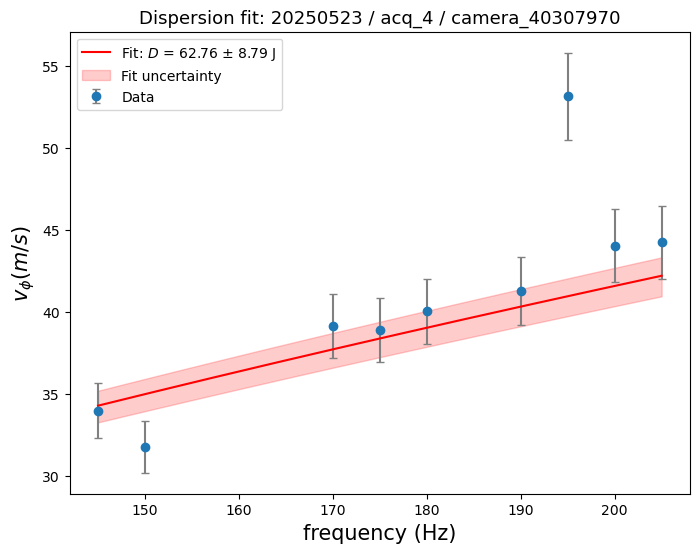

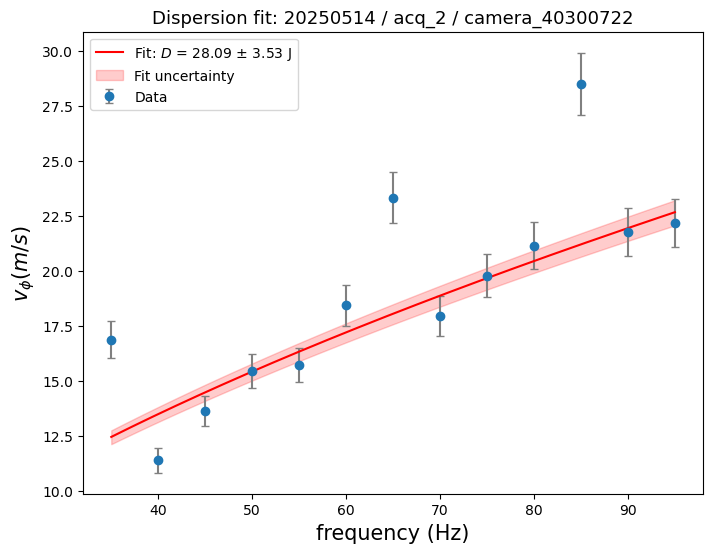

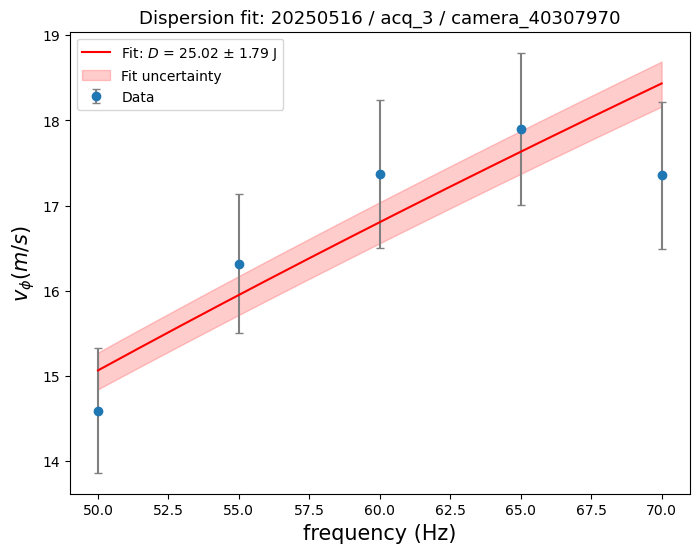

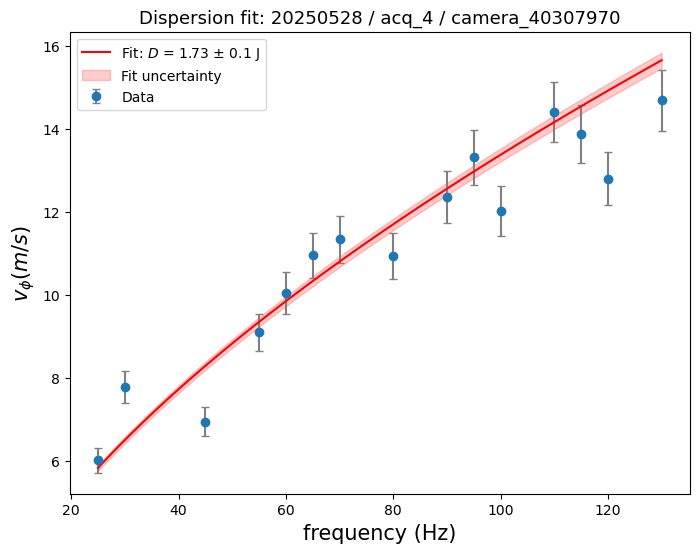

In [19]:
dates_choisies = ['20250527','20250527','20250513','20250526','20250523','20250514','20250516','20250528']
acq_choisies = ['acq_2','acq_3','acq_4','acq_5','acq_4','acq_2','acq_3','acq_4']
f_inf_choisis = [100,25,105,115,140,0,20,0] # csi : 65 au lieu de 115
f_sup_choisis = [np.inf,145,180,np.inf,210,100,80,np.inf]
cam_choisies = ['camera_40307970','camera_40307970','camera_40307970','camera_40300722','camera_40307970','camera_40300722','camera_40307970','camera_40307970']

E_choisis = []
E_err_choisis = []

h_choisis = []
h_std_choisis = []

D_choisis = []
D_err_choisis = []

for i in range(len(dates_choisies)):
    ddd, popt,pcov, tab_f_exc, tab_v_phase, tab_v_phase_err = plot_fit_onedataset(dates_choisies[i], acq_choisies[i], cam_choisies[i],bounds=(f_inf_choisis[i],f_sup_choisis[i]))
    E, E_err = compute_E(popt[0],ddd['h_avg_mm']*1e-3,ddd['h_std_mm']*1e-3)
    E_choisis.append(E)
    E_err_choisis.append(E_err)
    h_choisis.append(ddd['h_avg_mm']*1e-3)
    h_std_choisis.append(ddd['h_std_mm']*1e-3)
    D_choisis.append(popt[0])
    D_err_choisis.append(np.sqrt(pcov[0][0]))

E_choisis = np.array(E_choisis)
E_err_choisis = np.array(E_err_choisis)
h_choisis = np.array(h_choisis)
h_std_choisis = np.array(h_std_choisis)
D_choisis = np.array(D_choisis)

2.5671937445899498 1.0803283286329566


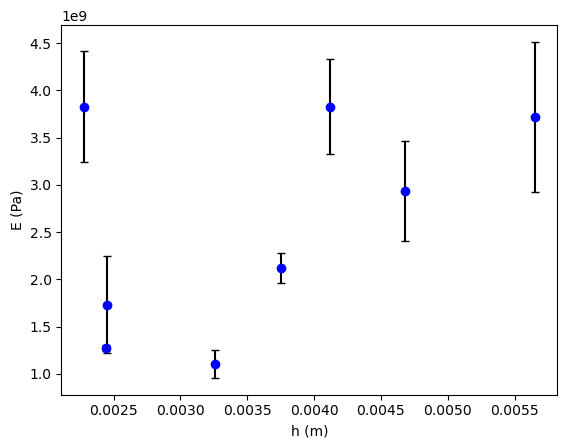

In [20]:
plt.errorbar(h_choisis,E_choisis,E_err_choisis,fmt='o',color='blue',ecolor='black',capsize=3)
plt.xlabel('h (m)')
plt.ylabel('E (Pa)')
#a,b,c = np.polyfit(h_choisis,E_choisis,2)
#h_fit = np.linspace(np.min(h_choisis),np.max(h_choisis))
#plt.plot(h_fit,a*h_fit**2+b*h_fit+c)
#print(a,b,c)
print(np.mean(E_choisis/1e9), np.std(E_choisis/1e9))

3.67027350463373 23.001583149278265
3.4807386546246013
[3.18748961e+08] [[4.5065797e+14]]
1.448548794500709
[1.32650989e+08] [[1.56914762e+15]]


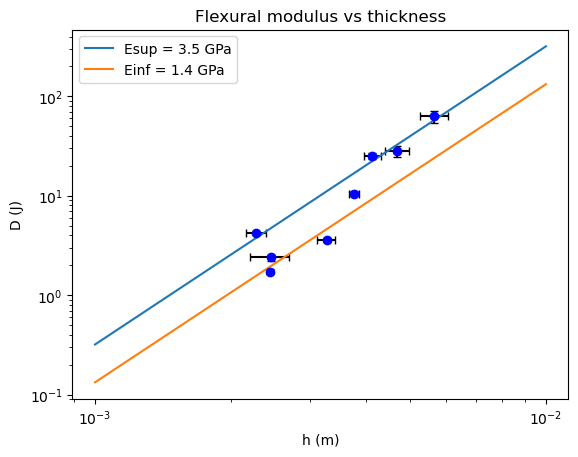

In [22]:
plt.errorbar(h_choisis,D_choisis,yerr=D_err_choisis,xerr=h_std_choisis,fmt='o',color='blue',ecolor='black',capsize=3)
hth = np.logspace(-3,-2)
#plt.plot(hth,6*(hth/3e-3)**3)
a,b = np.polyfit(np.log(h_choisis),np.log(D_choisis),1)
print(a,b)
#Emoy_fit = 12*(1-0.3**2) * np.exp(b)
#,label='fit : E = '+str(np.round(Emoy_fit*1e-9,3))+' GPa'
#plt.plot(hth,np.exp(b)*hth**(a),label='fit power law')

popt,pcov = curve_fit((lambda x,b:b*x**3),h_choisis,D_choisis)
Emoy_fit = 12*(1-0.3**2) * popt[0]
print(Emoy_fit*1e-9)
print(popt,pcov)
plt.plot(hth,popt[0]*hth**3,label='Esup = '+str(np.round(Emoy_fit*1e-9,1))+' GPa')


idcs_inf = np.where(h_choisis<3.5e-3)[0]
popt,pcov = curve_fit((lambda x,b:b*x**3),h_choisis[idcs_inf],D_choisis[idcs_inf])
Emoy_fit = 12*(1-0.3**2) * popt[0]
print(Emoy_fit*1e-9)
print(popt,pcov)
plt.plot(hth,popt[0]*hth**3,label='Einf = '+str(np.round(Emoy_fit*1e-9,1))+' GPa')

plt.loglog()
plt.xlabel('h (m)')
plt.ylabel('D (J)')
plt.title('Flexural modulus vs thickness')
plt.legend()
plt.savefig('resultats/figures/D_vs_h_best_acquisitions.pdf',dpi=300)
plt.show()


In [49]:
D_err_choisis

[np.float64(0.03372571781841579),
 np.float64(0.02845977585417713),
 np.float64(0.3388380555234701),
 np.float64(0.012088606235845971),
 np.float64(77.21029561098334),
 np.float64(12.451823325679367),
 np.float64(3.21790975023933),
 np.float64(0.010440141494797717)]

In [38]:
h_choisis[idcs_inf]

array([0.00326167, 0.00245333, 0.002278  , 0.00244   ])

## Etude en fonction de $\dot\epsilon$

[2, 4, 2, 2, 4, 4, 2, 2, 3, 3, 2, 2, 4, 4, 5, 5, 7, 7, 2, 3, 4]
['20250507', '20250507', '20250512', '20250513', '20250513', '20250513', '20250514', '20250514', '20250516', '20250516', '20250523', '20250523', '20250523', '20250523', '20250526', '20250526', '20250526', '20250526', '20250527', '20250527', '20250528']
Amplitude= 0.06883921101689339 +- 0.0016121865095501278 px
Amplitude= 0.07296350747346877 +- 0.0015716409682614203 px
Amplitude= 0.19312835335731507 +- 0.010026848654079929 px
Amplitude= 0.05554534085094928 +- 0.0018005083903787212 px
Amplitude= 0.21200341582298277 +- 0.004244875606001908 px
Amplitude= 0.06067122295498848 +- 0.003740497709972557 px
Amplitude= 0.21705319732427597 +- 0.004748457276849834 px
Amplitude= 0.13327417746186257 +- 0.014982369644844264 px
Amplitude= 0.08346766903996466 +- 0.0030728239659171095 px
Amplitude= 0.1974814921617508 +- 0.0037190090935824978 px
Amplitude= 0.10954883694648743 +- 0.0017396320069170282 px
Amplitude= 0.1637612983584404 +- 0.00235

[]

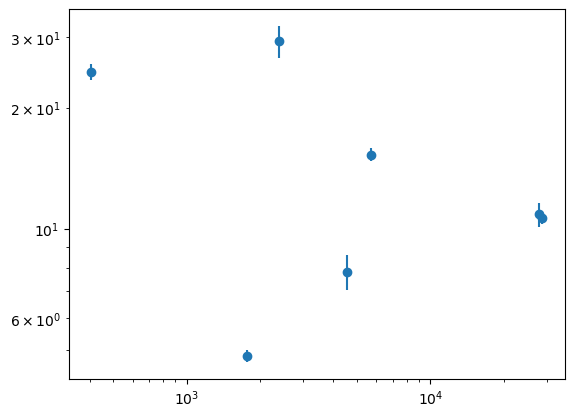

In [49]:
from rdd_epsilondot_dependence import extract_amplitude
print(dict_lists['list_acq_num'])
print(dict_lists['list_dates'])

#idx = 0

if system_loc=='windows_server':
    inputs_RDD_path = 'R:/Gre25/Summary/dispersion_relations/inputs_RDD.csv'
##linux_server
elif system_loc=='linux_server':
    inputs_RDD_path = '/media/turbots/GreDisk/Gre25/Summary/dispersion_relations/inputs_RDD.csv'


def load_profile_infos(idx, disk='R:',year='2025'):
    inputs_RDD_path = f'{disk}/Gre{year[-2:]}/Summary/dispersion_relations/inputs_RDD.csv'
    csv_data = pd.read_csv(inputs_RDD_path, sep=';')
    tab_ind_yprof = np.int64(csv_data['list_indices_y_potvib'].to_numpy()[1:])
    tab_ind_xinf = np.int64(csv_data['x_inf_fit'].to_numpy()[1:])
    tab_ind_xsup = np.int64(csv_data['x_sup_fit'].to_numpy()[1:])
    return tab_ind_yprof[idx], tab_ind_xinf[idx], tab_ind_xsup[idx]


def load_f_vs_vphase(idx):
    date = dict_lists['list_dates'][idx]
    acq = dict_lists['list_acq_num'][idx]
    cam = dict_lists['list_camera_SN'][idx]

    ddd = dict_results[date]['acq_'+str(acq)]['camera_'+cam]
    tab_v_phase = ddd['tab_v_phase']
    tab_v_phase_err = ddd['tab_v_phase_err']
    tab_f_exc = ddd['tab_f_exc']
    #mask = (tab_v_phase_err < 1/30*tab_v_phase) & (tab_v_phase>0)
    return tab_f_exc, tab_v_phase, tab_v_phase_err


def extract_amplitude_from_infosimgseq(date,acq,cam,fexc,facq,Dt,W,ind_yprof,ind_xinf,ind_xsup,disk='R:',plot=False,year='2025'):

    dir_matdata = f"{disk}/Gre{year[-2:]}/Data/{date}/cameras/manip_relation_dispersion/Acquisition_{acq}/camera_{cam}/{fexc}Hz_{facq}Hz/matData/"
    ldr = os.listdir(dir_matdata)
    matdata_name = None
    for elm in ldr:
        #print(elm)
        if elm.endswith('full.mat'):
            matdata_name = elm
        else:
            pass
    
    matdata_path = f'{dir_matdata}/{matdata_name}'
    
    amplitude, amplitude_err = extract_amplitude(matdata_path=matdata_path,ind_yprof=ind_yprof,ind_xinf=ind_xinf,ind_xsup=ind_xsup, plot=plot)
    return amplitude, amplitude_err

def extract_amplitude_from_idx_fexc(idx, fexc, dict_lists=dict_lists, dict_results=dict_results,disk='R:',plot=False):
    year = dict_lists['list_dates'][idx][:4]
    date = dict_lists['list_dates'][idx][-4:]
    acq = dict_lists['list_acq_num'][idx]
    cam = dict_lists['list_camera_SN'][idx]
    ddd = dict_results[year+date]['acq_'+str(acq)]['camera_'+cam]
    Dt = ddd['Dt']
    W = ddd['W']

    dir_cam = f"{disk}/Gre{year[-2:]}/Data/{date}/cameras/manip_relation_dispersion/Acquisition_{acq}/camera_{cam}/"
    ldr = os.listdir(dir_cam)
    facq = None
    for elm in ldr:
        if elm.startswith(f'{fexc}Hz'):
            facq = elm.split("_")[1].replace("Hz", "")

    #print(facq)
    ind_yprof,ind_xinf,ind_xsup = load_profile_infos(idx,disk=disk,year=year)
    amplitude, amplitude_err = extract_amplitude_from_infosimgseq(date=date,acq=acq,cam=cam,fexc=fexc,facq=facq,Dt=Dt,W=W,ind_yprof=ind_yprof,ind_xinf=ind_xinf,ind_xsup=ind_xsup,disk=disk,plot=plot,year=year)

    return amplitude, amplitude_err


def compute_effective_flexural_modulus(idx, fexc, rho_water=1e3):
    tab_f_exc, tab_v_phase, tab_v_phase_err = load_f_vs_vphase(idx)
    ifound = None
    for i in range(len(tab_f_exc)):
        if tab_f_exc[i] == fexc:
            ifound = i
            break
    vphase = tab_v_phase[ifound]
    vphase_err = tab_v_phase_err[ifound]
    
    D_eff = ((vphase**5)/((2*np.pi*fexc)**3))*rho_water
    D_eff_err = ((5*(vphase**4)*vphase_err)/((2*np.pi*fexc)**3))*rho_water # propagation de l'erreur de vphase sur D_eff

    return D_eff, D_eff_err

def compute_tabDeff_fromidx(idx, rho_water=1e3):
    tab_f_exc, tab_v_phase, tab_v_phase_err = load_f_vs_vphase(idx)
    tab_D_eff = np.zeros(len(tab_f_exc))
    tab_D_eff_err = np.zeros(len(tab_f_exc))
    for i in range(len(tab_f_exc)):
        tab_D_eff[i], tab_D_eff_err[i] = compute_effective_flexural_modulus(idx, tab_f_exc[i], rho_water=rho_water)
    return tab_D_eff, tab_D_eff_err, tab_f_exc, tab_v_phase, tab_v_phase_err

def extract_amplitudes_from_idxacq(idx,dict_lists=dict_lists, dict_results=dict_results,disk='R:',plot=False):
    tab_f_exc, _, _ = load_f_vs_vphase(idx)
    tab_amplitudes = np.zeros(len(tab_f_exc))
    tab_amplitudes_err = np.zeros(len(tab_f_exc))
    for i in range(len(tab_f_exc)):
        tab_amplitudes[i], tab_amplitudes_err[i] = extract_amplitude_from_idx_fexc(idx, tab_f_exc[i], dict_lists=dict_lists, dict_results=dict_results, disk=disk, plot=plot)
    return tab_amplitudes, tab_amplitudes_err

######################################
# test
#####################################

idx = 8

Dsa = {} # dsa pour "dict study vs amplitude"
Dsa['idx_'+str(idx)] = {}
Dsa_idx = Dsa['idx_'+str(idx)]

Dsa_idx['tab_D_eff'], Dsa_idx['tab_D_eff_err'], Dsa_idx['tab_f_exc'], Dsa_idx['tab_v_phase'], Dsa_idx['tab_v_phase_err']  = compute_tabDeff_fromidx(idx)

Dsa_idx['tab_amplitudes'], Dsa_idx['tab_amplitudes_err'] = extract_amplitudes_from_idxacq(idx,plot=False)

"""plt.figure()
plt.errorbar(Dsa_idx['tab_f_exc'], Dsa_idx['tab_D_eff'], yerr=Dsa_idx['tab_D_eff_err'])
plt.figure()
plt.errorbar(Dsa_idx['tab_f_exc'], Dsa_idx['tab_amplitudes'], yerr=Dsa_idx['tab_amplitudes_err'])"""

Dsa_idx['maskplot'] = (Dsa_idx['tab_D_eff_err']/Dsa_idx['tab_D_eff'] < 1/10)&(Dsa_idx['tab_D_eff']>0)&(Dsa_idx['tab_amplitudes']>0.15)
msk = Dsa_idx['maskplot']

plt.figure()
plt.errorbar(((2*np.pi)**2)*(Dsa_idx['tab_amplitudes'][msk]*(Dsa_idx['tab_f_exc'][msk]**3))/(2*Dsa_idx['tab_v_phase'][msk]**2),
              Dsa_idx['tab_D_eff'][msk], 
             yerr=Dsa_idx['tab_D_eff_err'][msk], 
             linestyle='',marker='o'
             ) # manque l'épaisseur au numerateur pour avoir qq chose prop. à taux de deformation (s^-1)
plt.loglog()

(array([2, 2, 1, 2, 4, 4, 4, 4, 5, 5, 5, 5, 4, 4, 3, 3, 3, 3, 2, 3, 3],
       dtype=int64),
 array([ 0,  0,  0,  0,  0, 15,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0,  0,
         0,  0,  0,  0], dtype=int64),
 array([25, 35, 40, 30, 35, 50, 30, 50, 30, 50, 30, 30, 40, 55, 30, 55, 35,
        55, 55, 55, 50], dtype=int64))